## 生成影像資料（GAN / Diffusion）

#### 步驟 1：環境準備與模型載入

In [ ]:
# ✅ 安裝 HuggingFace Diffusers（首次執行時啟用）
!pip install diffusers transformers accelerate scipy safetensors

In [ ]:
# from diffusers import StableDiffusionPipeline
# import torch

# pipe = StableDiffusionPipeline.from_pretrained(
#     "runwayml/stable-diffusion-v1-5",
#     safety_checker=None,                  # 關閉黑圖過濾
#     torch_dtype=torch.float32             # 1650Ti 不支援 float16
# ).to("cuda")

# pipe.enable_attention_slicing()
# print("✅ 模型載入完成")


##### 輕量模型

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float32,
    safety_checker=None
).to("cuda")

pipe.enable_attention_slicing()
print("✅ CompVis/stable-diffusion-v1-4 模型載入完成")

#### 步驟 2：設定類別與提示詞（prompt）

##### 測試用

In [ ]:
from diffusers import StableDiffusionPipeline
import torch, time

pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    safety_checker=None,                   # 完全禁用安全過濾
    torch_dtype=torch.float32,            # 確保是 float32 版本
).to("cuda")

pipe.enable_attention_slicing()

prompt = "A high-quality realistic photo of a car parked on a street in the daytime, full color, no distortion"
generator = torch.Generator(device="cuda").manual_seed(42)

start = time.time()
image = pipe(prompt, generator=generator, height=512, width=512).images[0]
elapsed = time.time() - start

print(f"✅ 生成時間：{elapsed:.2f} 秒")
image.save("test_car_v14_safe.jpg")
image.show()
torch.cuda.empty_cache()


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))
print("Current device:", pipe.device)


In [ ]:
class_prompts = {
    "car": "A realistic photo of a car parked on a street during the day",
    "dog": "A clear photo of a dog running on grass in daylight",
    "people": "A group of people walking on a sidewalk in a city in realistic."
}

num_images = 100
base_path = "data/fake"

#### 步驟 3：依類別生成影像資料

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.get_device_name(0))

In [ ]:
pipe.enable_attention_slicing()

In [ ]:
from PIL import Image
import os
from tqdm import tqdm
import time

for class_name, prompt in class_prompts.items():
    save_dir = os.path.join(base_path, class_name)
    os.makedirs(save_dir, exist_ok=True)

    print(f"\n🚀 正在生成類別：{class_name}")
    for i in tqdm(range(num_images)):
        generator = torch.Generator(device="cuda").manual_seed(i)
        
        start = time.time()
        image = pipe(prompt, generator=generator, height=512, width=512).images[0]
        elapsed = time.time() - start

        filename = f"{save_dir}/fake_{class_name}_{i:04d}.jpg"
        image.save(filename)

        torch.cuda.empty_cache()  # 清理 VRAM，防爆記憶體
        print(f"✅ 生成 {filename}，耗時 {elapsed:.2f} 秒")

    print(f"🎉 {class_name} 類別圖像生成完畢，儲存於 {save_dir}")

#### 步驟四：檢查資料夾結構

In [ ]:
# 📁 檢查生成結果
for class_name in class_prompts:
    folder = os.path.join(base_path, class_name)
    files = os.listdir(folder)
    print(f"{class_name}: 共 {len(files)} 張影像")

#### 複製 real image 對照

In [ ]:
import os
import random
import shutil

def get_image_ids_with_class(txt_path):
    """
    讀取像 car_trainval.txt 檔案，回傳其中 flag==1 的 image_ids
    """
    image_ids = []
    with open(txt_path, 'r') as f:
        for line in f:
            # e.g. "000012 1"
            parts = line.strip().split()
            if len(parts) == 2:
                img_id, flag = parts
                if flag == '1':  # 表示該圖有此類別
                    image_ids.append(img_id)
    return image_ids

def copy_voc_images_for_class(voc_root, class_name, image_set='trainval', num_images=100, dst_root='data/real'):
    """
    從 Pascal VOC2007 中，隨機複製指定類別(如car/dog/person)的num_images張圖到 data/real/<class_name>。
    voc_root: VOC2007 路徑，如 .../VOCdevkit/VOC2007
    class_name: car/dog/person (對應 .txt檔案裡的關鍵字)
    image_set: 'trainval' or 'test'
    """
    # 1) 找到對應txt檔 e.g. "car_trainval.txt"
    txt_path = os.path.join(voc_root, 'ImageSets', 'Main', f'{class_name}_{image_set}.txt')
    if not os.path.exists(txt_path):
        raise FileNotFoundError(f"找不到 {txt_path}, 請確認 Pascal VOC 有這個檔案")

    # 2) 收集所有有此類別的image_id
    image_ids = get_image_ids_with_class(txt_path)
    print(f"{class_name}_{image_set}: 總共有 {len(image_ids)} 張圖含有{class_name}")

    # 3) 隨機挑選 or 全部
    if len(image_ids) > num_images:
        image_ids = random.sample(image_ids, num_images)

    # 4) 複製到 data/real/<class_name> 目錄
    dst_folder = os.path.join(dst_root, class_name)
    os.makedirs(dst_folder, exist_ok=True)

    jpeg_folder = os.path.join(voc_root, 'JPEGImages')
    for img_id in image_ids:
        src_img = os.path.join(jpeg_folder, f"{img_id}.jpg")
        dst_img = os.path.join(dst_folder, f"{img_id}.jpg")
        shutil.copy(src_img, dst_img)

    print(f"✅ 已複製 {len(image_ids)} 張 {class_name} 圖至 {dst_folder}")



In [ ]:
%cd Week5

In [ ]:
voc_root = ".\VOCdevkit\VOCdevkit\VOC2007"  # 你的 VOC2007 目錄
dst_root = "./data/real"

# 針對 car, dog, person，各複製 100 張
copy_voc_images_for_class(voc_root, class_name="car", image_set="trainval", num_images=100, dst_root=dst_root)
copy_voc_images_for_class(voc_root, class_name="dog", image_set="trainval", num_images=100, dst_root=dst_root)
copy_voc_images_for_class(voc_root, class_name="person", image_set="trainval", num_images=100, dst_root=dst_root)


## 步驟 2️⃣：提取通道激活圖（Hook 註冊 + 激活擷取）

#### 通道激活分析 提取 conv3, conv5 的 feature maps，並計算 mean / max per channel。

In [ ]:
%cd ..

In [ ]:
# 📦 基礎匯入
import torch
import torchvision.transforms as transforms
from PIL import Image
import os
import json
import numpy as np
from tqdm import tqdm
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

# 🧠 OS2D 模型與設定
from os2d.modeling.model import build_os2d_from_config
from os2d.config import cfg
from os2d.utils import setup_logger

# 📝 建立 logger
logger = setup_logger("OS2D")

# ✅ GPU / CPU 裝置選擇
cfg.is_cuda = torch.cuda.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ 載入 OS2D 預訓練模型 (請確認 .pth 路徑正確)
cfg.init.model = "models/os2d_v2-train.pth"
net, box_coder, criterion, img_normalization, optimizer_state = build_os2d_from_config(cfg)
net.eval()

print("OS2D 模型結構:\n", net)

# ✅ 只掛載 layer3 的 hook (因為沒有 layer4)
activations = {}

# 在 OS2D 初始化之後執行：
net.net_feature_maps.layer3.register_forward_hook(
    lambda m, i, o: activations.update({'conv3': o.detach()})
)


# ✅ 圖片前處理 (與 OS2D 訓練一致)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=img_normalization["mean"], std=img_normalization["std"])
])

print("\n✅ 模型與通道 Hook 設定完成，現在可用 'activations[\"conv3\"]' 取得特徵。")


In [55]:
def compute_backbone_feature(img_path, layer_name="conv3"):
    """
    讀取 img_path，呼叫 net.net_feature_maps(img_tensor) 取得 layer3 特徵。
    回傳 (mean_vec, max_vec) 兩個 numpy array。
    """

    # 1) 載入並 transform
    image = Image.open(img_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)

    # 2) 每次 forward 前清空
    activations[layer_name] = None

    # 3) 只呼叫 backbone forward，不用 net(...) 這個 detection pipeline
    with torch.no_grad():
        net.net_feature_maps(img_tensor)  # ← 關鍵之處

    # 4) 取得 hook 的輸出
    feat = activations[layer_name].squeeze(0)  # [C, H, W]

    # flatten => [C, H*W]  (因舊版 PyTorch 不支援 dim=(1,2))
    feat_flat = feat.view(feat.shape[0], -1)
    mean_vec = feat_flat.mean(dim=1).cpu().numpy()
    max_vec  = feat_flat.max(dim=1)[0].cpu().numpy()

    return mean_vec, max_vec

def process_folder_backbone(folder_path, layer_name="conv3"):
    mean_all, max_all = [], []
    for fname in tqdm(sorted(os.listdir(folder_path))):
        if fname.lower().endswith(".jpg"):
            img_path = os.path.join(folder_path, fname)
            mean_vec, max_vec = compute_backbone_feature(img_path, layer_name)
            mean_all.append(mean_vec)
            max_all.append(max_vec)
    return np.array(mean_all), np.array(max_all)


###  步驟 3️⃣：相似度分析

##### 比較真實 vs 生成影像，使用 cosine similarity 判斷通道異常

In [60]:
def similarity_analysis_backbone(layer_name="conv3", threshold=0.6):
    class_list = ["car", "dog", "person"]
    abnormal_channels_all = {}

    for cls in class_list:
        print(f"\n🔍 分析類別：{cls} (層: {layer_name})")
        real_path = f"data/real/{cls}"
        fake_path = f"data/fake/{cls}"

        real_mean, _ = process_folder_backbone(real_path, layer_name)
        fake_mean, _ = process_folder_backbone(fake_path, layer_name)

        sim_scores = []
        abnormal_channels = []

        for r_vec, f_vec in zip(real_mean, fake_mean):
            sim = cosine_similarity([r_vec], [f_vec])[0][0]
            sim_scores.append(sim)
            if sim < threshold:
                diff = np.abs(r_vec - f_vec)
                bad_idx = np.where(diff > 0.3)[0].tolist()
                abnormal_channels.extend(bad_idx)

        abnormal_channels_all[cls] = abnormal_channels
        np.savetxt(f"cosine_similarity_{layer_name}_{cls}.csv", sim_scores, delimiter=",")
        print(f"✅ {cls} 平均相似度: {np.mean(sim_scores):.4f}，異常通道數: {len(abnormal_channels)}")

    return abnormal_channels_all


In [61]:
# ab_channels = similarity_analysis_backbone(layer_name="conv3", threshold=0.6)
# compute_prune_score(ab_channels, layer_name="conv3")

### 步驟 4️⃣：異常通道紀錄與剪枝分數生成

#### 輸出 JSON 統計結果：abnormal_channel_log_{layer}.json、prune_candidate_score_{layer}.json

In [62]:
def compute_prune_score(abnormal_channels_all, layer_name="conv3"):
    """
    將 abnormal_channels_all 聚合，計算每個 channel 出現異常的頻率 / 總異常數量，
    輸出 2 個 JSON 檔案:
     1. abnormal_channel_log_{layer_name}.json
     2. prune_candidate_score_{layer_name}.json
    """
    from collections import Counter
    import json

    flat_ab = [c for sublist in abnormal_channels_all.values() for c in sublist]
    if not flat_ab:
        print("⚠️ 未出現異常通道，可能 threshold 過低或真/假圖像差異太小。")
        return

    ab_counter = Counter(flat_ab)
    total = sum(ab_counter.values())

    # 剪枝分數 = 出現異常次數 / 總異常次數
    prune_score = {str(k): round(v / total, 4) for k, v in ab_counter.items()}

    # 儲存
    with open(f"abnormal_channel_log_{layer_name}.json", 'w') as f:
        json.dump(dict(ab_counter), f, indent=2)

    with open(f"prune_candidate_score_{layer_name}.json", 'w') as f:
        json.dump(prune_score, f, indent=2)

    print(f"✅ [層: {layer_name}] 剪枝分數完成, 通道數: {len(prune_score)}")
    # 顯示前 5 大異常通道
    top5 = sorted(prune_score.items(), key=lambda x: x[1], reverse=True)[:5]
    print("前5名異常通道:", top5)

### 實驗開始

In [63]:
ab_channels = similarity_analysis_backbone(layer_name="conv3", threshold=0.6)
compute_prune_score(ab_channels, layer_name="conv3")



🔍 分析類別：car (層: conv3)


100%|██████████| 100/100 [00:01<00:00, 82.71it/s]


✅ car 平均相似度: 0.7841，異常通道數: 0

🔍 分析類別：dog (層: conv3)


100%|██████████| 100/100 [00:01<00:00, 76.22it/s]


✅ dog 平均相似度: 0.7544，異常通道數: 436

🔍 分析類別：person (層: conv3)


100%|██████████| 100/100 [00:01<00:00, 81.77it/s]

✅ person 平均相似度: 0.7805，異常通道數: 0
✅ [層: conv3] 剪枝分數完成, 通道數: 436
前5名異常通道: [('3', 0.0023), ('6', 0.0023), ('9', 0.0023), ('10', 0.0023), ('12', 0.0023)]


### 可視化

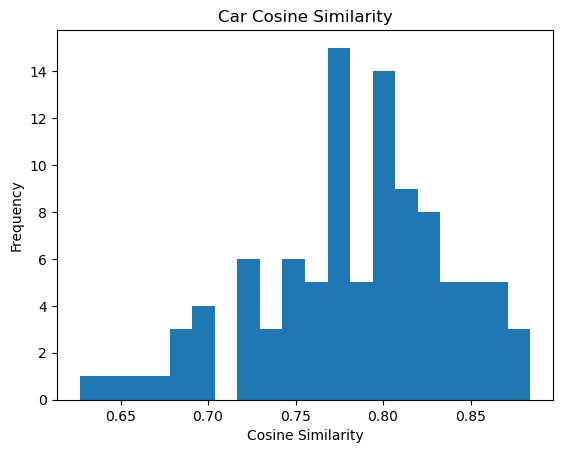

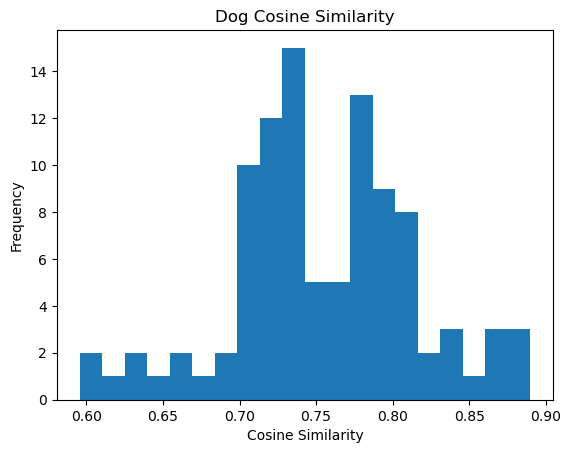

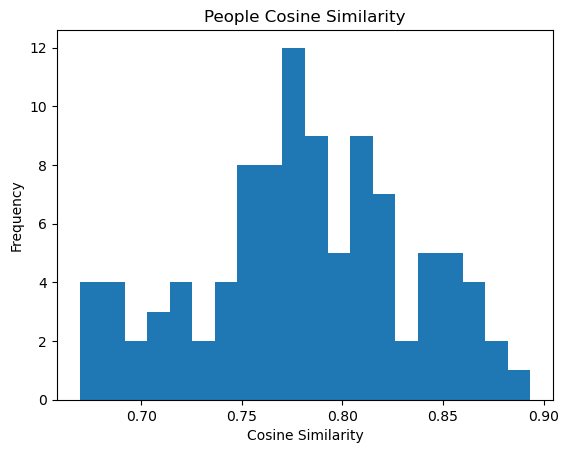

In [69]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cosine_distribution(csv_path, title="Cosine Similarity Distribution"):
    """
    讀取 csv，將其中的相似度值繪成直方圖。
    """
    # 1) 讀取 csv
    sim_scores = np.loadtxt(csv_path + ".csv", delimiter=",")
    # 2) 繪製圖
    plt.figure()  # 每張圖單獨 figure
    plt.hist(sim_scores, bins=20)  # 直方圖
    plt.title(title)
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Frequency")
    plt.savefig( "./image/" + csv_path+".png" )
    plt.show()

# 範例呼叫
plot_cosine_distribution("cosine_similarity_conv3_car", title="Car Cosine Similarity")
plot_cosine_distribution("cosine_similarity_conv3_dog", title="Dog Cosine Similarity")
plot_cosine_distribution("cosine_similarity_conv3_person", title="People Cosine Similarity")


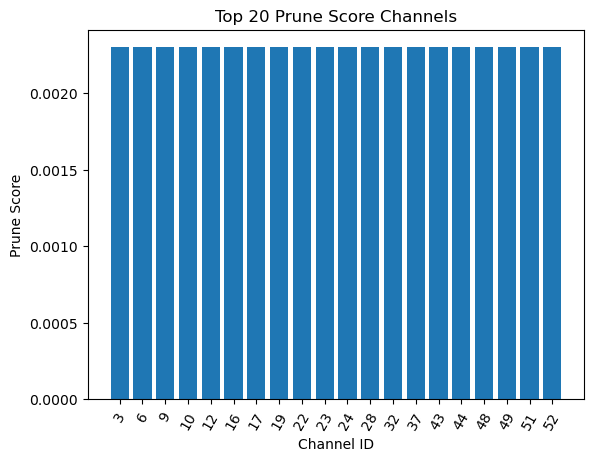

In [70]:
import json
import matplotlib.pyplot as plt

def plot_prune_score(json_path, top_n=20):
    """
    讀取 prune_candidate_score_conv3.json，
    只呈現其中分數最高的 top_n 通道，以 bar chart 顯示。
    """
    with open(json_path, 'r') as f:
        prune_dict = json.load(f)  # {channel_id: score, ...}

    # 轉成 (channel, score) 列表
    items = [(int(k), v) for k, v in prune_dict.items()]
    # 依 score 降序
    items.sort(key=lambda x: x[1], reverse=True)

    # 取前 top_n
    top_items = items[:top_n]
    channels = [str(x[0]) for x in top_items]
    scores = [x[1] for x in top_items]

    plt.figure()
    plt.bar(channels, scores)
    plt.title(f"Top {top_n} Prune Score Channels")
    plt.xlabel("Channel ID")
    plt.ylabel("Prune Score")
    plt.xticks(rotation=60)
    plt.savefig( "./Image/prune_candidate_score_conv3.png" )
    plt.show()

# 範例呼叫
plot_prune_score("prune_candidate_score_conv3.json", top_n=20)
